# 10 - Segmentation (RQ4) and segment-level aspect rankings

- Table 16: expressed satisfaction by language group on the full modelling set (chi-square with Yates's correction, phi, Cohen's h, odds ratio, CI on the percentage-point difference).
- RQ4b: the per-language kappa from notebook 05 is read back and placed beside Table 16 so the two can be interpreted together.
- Segment-level aspect rankings by language, platform and entity, with a divergence table against the overall ranking from notebook 09.
- Model performance by platform and by entity for the best model.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# make src importable when the kernel starts inside notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
from src import config
from src.io import ensure_dirs, save_table, update_metrics, read_metrics
ensure_dirs()

In [2]:
from src.stats import two_proportion_comparison, aspect_association
from src.aspects import add_aspect_columns, ASPECTS, ASPECT_DISPLAY
from src.evaluation import per_segment_metrics
from src.io import load_predictions

modelling = add_aspect_columns(pd.read_parquet(config.MODELLING_FILE))
aspect_cols = [f"aspect_{a}" for a in ASPECTS]
metrics = read_metrics()

## Table 16 - expressed satisfaction by language (RQ4a)

In [3]:
en = modelling[modelling.language == "English"]; ar = modelling[modelling.language == "Arabic"]
dis = lambda d: int((d.satisfaction_label == config.DISSATISFIED_LABEL).sum())
cmp = two_proportion_comparison(dis(en), len(en), dis(ar), len(ar))
t16 = pd.DataFrame([
    {"statistic": "Dissatisfied share, English", "value": f"{cmp['rate_a']*100:.1f}%", "basis": f"{dis(en):,} / {len(en):,}"},
    {"statistic": "Dissatisfied share, Arabic", "value": f"{cmp['rate_b']*100:.1f}%", "basis": f"{dis(ar):,} / {len(ar):,}"},
    {"statistic": "Difference (95% CI)", "value": f"{cmp['diff_pp']:.1f} pp", "basis": f"[{cmp['diff_ci_low_pp']:.1f}, {cmp['diff_ci_high_pp']:.1f}]"},
    {"statistic": "Pearson chi-square (df = 1)", "value": f"{cmp['chi2_yates']:.2f}", "basis": f"p {'< .001' if cmp['p'] < .001 else '= ' + format(cmp['p'], '.3f')}"},
    {"statistic": "Phi", "value": f"{cmp['phi']:.3f}", "basis": ""},
    {"statistic": "Cohen's h", "value": f"{cmp['cohens_h']:.3f}", "basis": ""},
    {"statistic": "Odds ratio", "value": f"{cmp['odds_ratio']:.2f}", "basis": ""},
])
save_table(t16, "table16_language_comparison")
print(f"N = {cmp['n']:,}")
t16

N = 48,930


,statistic,value,basis
0,"Dissatisfied share, English",59.8%,"22,145 / 37,061"
1,"Dissatisfied share, Arabic",42.5%,"5,045 / 11,869"
2,Difference (95% CI),17.2 pp,"[16.2, 18.3]"
3,Pearson chi-square (df = 1),1082.41,p < .001
4,Phi,0.149,
5,Cohen's h,0.347,
6,Odds ratio,2.01,


## RQ4b - measurement equivalence (kappa by language, from notebook 05)

In [4]:
kappa = pd.read_csv(config.TABLES_DIR / "table17_kappa.csv")
k = kappa.set_index("stratum")
overlap = not (k.loc["English", "ci_high"] < k.loc["Arabic", "ci_low"] or k.loc["Arabic", "ci_high"] < k.loc["English", "ci_low"])
same_band = k.loc["English", "band"] == k.loc["Arabic", "band"]
verdict = ("equivalent" if (overlap and same_band) else "non-equivalent")
print(kappa.round(3).to_string(index=False))
print(f"\nintervals overlap: {overlap}   same Landis-Koch band: {same_band}   -> label is {verdict} across languages")
print("Therefore the Table 16 difference is interpreted as a difference in", "expressed satisfaction." if verdict == "equivalent" else "measurement, not necessarily in satisfaction.")

                      stratum   n  observed_agreement  kappa  ci_low  ci_high           band
                      English 192               0.927  0.854   0.778    0.924 Almost perfect
                       Arabic 193               0.938  0.876   0.804    0.938 Almost perfect
                      Overall 385               0.932  0.865   0.813    0.912 Almost perfect
Intra-annotator (second pass)  76               0.987  0.974   0.919    1.000 Almost perfect

intervals overlap: True   same Landis-Koch band: True   -> label is equivalent across languages
Therefore the Table 16 difference is interpreted as a difference in expressed satisfaction.


## Segment-level aspect rankings and divergence from the overall ranking

In [5]:
overall = pd.read_csv(config.TABLES_DIR / "table15_aspects.csv").set_index("aspect")["rank"]

def seg_rank(d, min_n=300):
    if len(d) < min_n or d.satisfaction_label.nunique() < 2:
        return None
    t = aspect_association(d, aspect_cols, "satisfaction_label", config.DISSATISFIED_LABEL)
    t["aspect"] = t.aspect.str.replace("aspect_", "")
    t["rank"] = range(1, len(t) + 1)
    return t.set_index("aspect")

rows = []
segments = {("language", l): modelling[modelling.language == l] for l in config.LANGUAGES}
segments.update({("platform", p): modelling[modelling.platform == p] for p in modelling.platform.unique()})
top_apps = modelling.app_name.value_counts()
top_apps = top_apps[top_apps >= 500].index
segments.update({("entity", a): modelling[modelling.app_name == a] for a in top_apps})

for (kind, name), d in segments.items():
    t = seg_rank(d)
    if t is None: continue
    for a in t.index:
        rows.append({"segment_type": kind, "segment": name, "n": len(d), "aspect": a, "segment_rank": int(t.loc[a, "rank"]),
                     "overall_rank": int(overall[a]), "rank_shift": int(overall[a] - t.loc[a, "rank"]),
                     "risk_ratio": t.loc[a, "risk_ratio"], "p_adj": t.loc[a, "p_adj"], "n_mentions": int(t.loc[a, "n_mentions"])})
seg = pd.DataFrame(rows)
save_table(seg, "segment_aspect_rankings")
print(f"segments ranked: {seg.groupby(['segment_type','segment']).ngroups}")

# top aspect per segment and the biggest divergences
top_per_seg = seg[seg.segment_rank == 1][["segment_type", "segment", "n", "aspect", "overall_rank", "risk_ratio"]]
save_table(top_per_seg, "segment_top_aspect")
top_per_seg

segments ranked: 28


,segment_type,segment,n,aspect,overall_rank,risk_ratio
0,language,Arabic,11869,login,2,7.009064
10,language,English,37061,performance,1,7.063751
20,platform,Google Play,39721,performance,1,7.310702
30,platform,App Store,9209,performance,1,7.800374
40,entity,RTA Dubai,5352,login,2,12.872325
50,entity,RTA Smart Drive,5121,performance,1,5.799679
60,entity,UAE PASS,4819,performance,1,3.787043
70,entity,UAEICP,3280,registration,3,10.483094
80,entity,MOHRE,2739,login,2,5.455223
90,entity,MOI UAE,2531,performance,1,6.567948


In [6]:
div = seg[(seg.rank_shift.abs() >= 3) & (seg.n_mentions >= 30)].sort_values("rank_shift", key=abs, ascending=False)
save_table(div, "segment_divergences")
print("largest rank divergences from the overall ranking (|shift| >= 3, >= 30 mentions):")
div.head(20).round(3)

largest rank divergences from the overall ranking (|shift| >= 3, >= 30 mentions):


,segment_type,segment,n,aspect,segment_rank,overall_rank,rank_shift,risk_ratio,p_adj,n_mentions
268,entity,TAQA Distribution AD,606,performance,9,1,-8,NaN,0.000,71
172,entity,Esaad Card,978,usability,3,10,7,1.139,1.000,33
110,entity,S'hail,1404,payment,1,7,6,6.127,0.099,71
114,entity,S'hail,1404,usability,5,10,5,0.538,0.001,243
264,entity,TAQA Distribution AD,606,support,5,9,4,1.108,0.931,33
255,entity,Darbi (ITC),694,usability,6,10,4,1.314,0.522,74
232,entity,Parkin,707,payment,3,7,4,2.030,0.001,275
202,entity,SEHA,781,payment,3,7,4,3.380,0.047,67
134,entity,DubaiNow,1149,performance,5,1,-4,3.333,0.000,164
165,entity,AWQAF UAE,1022,usability,6,10,4,0.989,1.000,87


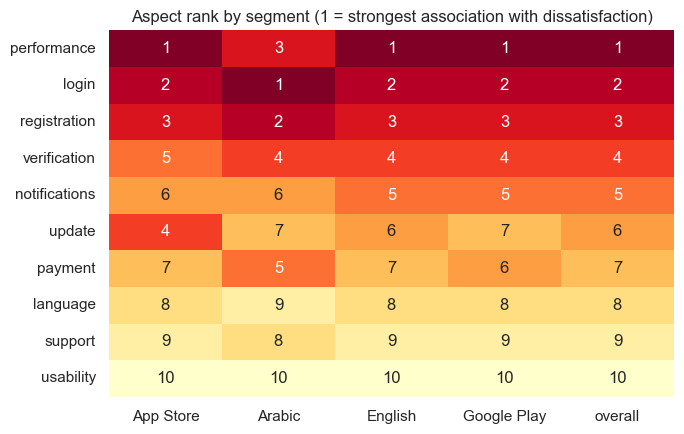

In [7]:
pivot = seg[seg.segment_type != "entity"].pivot_table(index="aspect", columns="segment", values="segment_rank")
pivot["overall"] = overall
pivot = pivot.sort_values("overall")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, cmap="YlOrRd_r", cbar=False, ax=ax)
ax.set(title="Aspect rank by segment (1 = strongest association with dissatisfaction)", xlabel="", ylabel="")
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig_aspect_rank_by_segment.png", dpi=220); plt.show()

## Best-model performance by platform and entity

In [8]:
preds = load_predictions()
best = metrics.get("comparison", {}).get("best_overall")
test = pd.read_parquet(config.SPLIT_FILES["test"])
if best in preds:
    p = preds[best].merge(test[["review_id", "language", "platform", "app_name"]], on="review_id")
    by_platform = per_segment_metrics(p, p.y_true, p.y_pred, "platform")
    big = p.app_name.value_counts(); big = big[big >= 100].index
    by_entity = per_segment_metrics(p[p.app_name.isin(big)], p[p.app_name.isin(big)].y_true, p[p.app_name.isin(big)].y_pred, "app_name").sort_values("macro_f1")
    save_table(by_platform, "perf_by_platform"); save_table(by_entity, "perf_by_entity")
    print(config.MODEL_DISPLAY[best]); display(by_platform.round(4)); display(by_entity.round(4))

XLM-RoBERTa (base)


,platform,n,macro_f1,recall_Dissatisfied,recall_Satisfied,accuracy_secondary
0,App Store,1405,0.9249,0.9645,0.8752,0.9288
1,Google Play,5935,0.9276,0.9474,0.9056,0.9284


,app_name,n,macro_f1,recall_Dissatisfied,recall_Satisfied,accuracy_secondary
0,AWQAF UAE,166,0.7496,0.8519,0.6379,0.7771
13,RTA Smart Drive,790,0.8506,0.7308,0.9705,0.9468
7,Esaad Card,144,0.8512,0.9921,0.6111,0.9444
21,nol Pay,151,0.8514,0.9603,0.7200,0.9205
15,SEHA,110,0.8537,0.9574,0.7500,0.9273
19,UAE PASS,666,0.8558,0.9548,0.7333,0.9099
9,MOHRE,400,0.8655,0.9474,0.7801,0.8675
2,Darbi (ITC),100,0.8901,0.9375,0.8333,0.9000
16,Smart Salik,137,0.8916,0.9469,0.8750,0.9343
4,Dubai Police,312,0.8987,0.8676,0.9467,0.9295


In [9]:
update_metrics("segmentation", {
    "table16": {**cmp, "rows": t16.to_dict(orient="records")},
    "rq4b": {"overlap": bool(overlap), "same_band": bool(same_band), "verdict": verdict,
             "kappa_english": float(k.loc["English", "kappa"]), "kappa_arabic": float(k.loc["Arabic", "kappa"])},
    "top_aspect_per_segment": top_per_seg.to_dict(orient="records"),
    "divergences": div.head(15).to_dict(orient="records"),
})
print("metrics updated")

metrics updated
